<a href="https://colab.research.google.com/github/mikecrv2019-bit/MAESTRIA-IA/blob/main/MAI540_Modulo1_Tarea1_2_Laboratorio_Desarrollo_Asistido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAI540 – Módulo 1 – Tarea 1.2: Laboratorio de Desarrollo Asistido
**Customer Service AI Chatbot: predicción de clientes insatisfechos**

Problema: clasificación binaria. Clase positiva: **Insatisfecho = Yes** (`customer_satisfaction` ≤ 2).
Se ejecuta en Google Colab con *Entorno de ejecución → Ejecutar todo*. Los datos (4.500 filas) se leen desde el repositorio de GitHub; si no hubiera conexión, la celda de carga pide subir `datos.csv`.

| Sección | Contenido |
|---|---|
| 1 | Carga y comprensión de los datos |
| 2 | ANTES: modelo original (3 variables numéricas) |
| 3 | DESPUÉS: 10 variables + `ColumnTransformer` + `class_weight="balanced"` |
| 4 | Comparación ANTES vs DESPUÉS |
| 5 | Verificaciones |
| 6 | Explicación propia |

## 1. Carga y comprensión de los datos

In [ ]:
import pandas as pd

URL = ("https://raw.githubusercontent.com/mikecrv2019-bit/MAESTRIA-IA/main/"
       "MAI540_Modulo%201_Tarea%201.2_Laoratorio_Desarrollo_Asistido/data/datos.csv")
try:
    df = pd.read_csv(URL)
    print("Datos cargados desde GitHub")
except Exception:
    # Respaldo: subir manualmente el archivo datos.csv
    from google.colab import files
    print("No se pudo leer desde GitHub. Sube el archivo datos.csv:")
    files.upload()
    df = pd.read_csv("datos.csv")

print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")
print("\nValores nulos por columna (solo las que tienen):")
print(df.isna().sum()[lambda s: s > 0] if df.isna().any().any() else "ninguno")
print("\nProporción de insatisfechos (customer_satisfaction <= 2):",
      round((df["customer_satisfaction"] <= 2).mean(), 4))
print("\nRango de customer_sentiment:", df["customer_sentiment"].min(), "a", df["customer_sentiment"].max(),
      "(la descripción dice 0 a 1)")
df.head()

Datos cargados desde GitHub
Filas: 4,500 | Columnas: 13

Valores nulos por columna (solo las que tienen):
ninguno

Proporción de insatisfechos (customer_satisfaction <= 2): 0.1996

Rango de customer_sentiment: -0.72 a 1.0 (la descripción dice 0 a 1)


,interaction_id,timestamp,query_type,handled_by,response_time_min,resolution_status,customer_sentiment,customer_satisfaction,interaction_cost_usd,customer_id,region,device_type,follow_up_required
0,ba69ef7b-9af5-41b0-9212-03d490ff492a,2024-04-20,Billing Question,Human Agent,6.24,Resolved,0.53,5,6.17,ce423304-e41b-4dcf-a2f4-cd15c37dee96,Kansas,Desktop,False
1,551ccbb2-d357-4cfd-93b5-d477a94f5d47,2024-04-29,Password Reset,AI Chatbot,1.68,Resolved,0.49,4,3.54,7cb73353-e50f-4e2c-8028-ff754b2bd990,Michigan,Desktop,False
2,58be735e-fb23-4f5f-86ca-97de5e7d54cd,2024-05-12,Technical Support,AI Chatbot,1.49,Resolved,0.47,4,3.60,f957576f-2bfd-422f-b8aa-23d61cfa5842,Indiana,Mobile,False
3,07fc08ca-dda6-4ea4-857b-cf86c2958860,2024-05-24,Billing Question,AI Chatbot,0.94,Resolved,-0.06,4,2.97,03fce315-ab4d-44f2-a6f7-81ec9a17d582,Connecticut,Tablet,True
4,2f51355f-4891-4ba8-874b-d637deb78e80,2024-05-01,Shipping Inquiry,Human Agent,5.29,Pending,0.09,2,5.63,56e5f1d5-5e5f-48ba-8f57-60a02735ab41,Massachusetts,Mobile,False


## 2. ANTES: modelo original
Regresión logística con imputación por mediana y solo 3 variables numéricas. Se usa el mismo split (`test_size=0.25`, `random_state=42`, `stratify=y`) que en el modelo final, para que la comparación sea justa.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# timestamp viene como texto: se convierte a fecha y se extrae el nombre del día
df["dia_semana"] = pd.to_datetime(df["timestamp"]).dt.day_name()
# follow_up_required es booleana: se trata como categórica
df["follow_up_required"] = df["follow_up_required"].astype(str)

# Objetivo: 1 = Insatisfecho. customer_satisfaction NO se usa como predictor (fuga de información)
y = (df["customer_satisfaction"] <= 2).astype(int)

num_cols = ["response_time_min", "interaction_cost_usd", "customer_sentiment"]
cat_cols = ["handled_by", "query_type", "resolution_status",
            "follow_up_required", "device_type", "region", "dia_semana"]
features_antes = num_cols
features_despues = num_cols + cat_cols   # exactamente las 10 variables del enunciado

X_train, X_test, y_train, y_test = train_test_split(
    df[features_despues], y, test_size=0.25, random_state=42, stratify=y
)

antes = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])
antes.fit(X_train[features_antes], y_train)
pred_antes = antes.predict(X_test[features_antes])

print("=== ANTES ===")
print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Insatisfechos en test: {int(y_test.sum())}")
print(f"Variables: {len(features_antes)}")
print(f"Accuracy: {accuracy_score(y_test, pred_antes):.4f}")
print("Matriz de confusión (filas=real, columnas=predicho; 0=No, 1=Yes):")
print(confusion_matrix(y_test, pred_antes))

=== ANTES ===
Train: 3,375 | Test: 1,125 | Insatisfechos en test: 224
Variables: 3
Accuracy: 0.8009
Matriz de confusión (filas=real, columnas=predicho; 0=No, 1=Yes):
[[901   0]
 [224   0]]


**Lectura del ANTES:** el modelo predice «No» para todos los casos de prueba. Su accuracy (0,80) es simplemente la proporción de la clase mayoritaria: no detecta a ningún insatisfecho (recall = 0).

## 3. DESPUÉS: modelo mejorado
- 10 variables: 3 numéricas + 7 categóricas (incluida `dia_semana`).
- `ColumnTransformer`: numéricas → mediana + `StandardScaler`; categóricas → moda + `OneHotEncoder(handle_unknown="ignore")`.
- `LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")`.
- Todo el preprocesamiento va dentro del `Pipeline`, así que se ajusta **solo con los datos de entrenamiento**.

In [ ]:
preprocesamiento = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

despues = Pipeline([
    ("prep", preprocesamiento),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
])
despues.fit(X_train, y_train)          # el preprocesamiento aprende solo de X_train
pred_despues = despues.predict(X_test)

print("=== DESPUÉS ===")
print(f"Variables: {len(features_despues)}")
print("Matriz de confusión (filas=real, columnas=predicho; 0=No, 1=Yes):")
print(confusion_matrix(y_test, pred_despues))

=== DESPUÉS ===
Variables: 10
Matriz de confusión (filas=real, columnas=predicho; 0=No, 1=Yes):
[[764 137]
 [ 65 159]]


## 4. Comparación ANTES vs DESPUÉS (clase positiva: Insatisfecho = Yes)

In [ ]:
def metricas(pred):
    return {
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred, zero_division=0),
        "F1":        f1_score(y_test, pred, zero_division=0),
    }

comparacion = pd.DataFrame({"ANTES": metricas(pred_antes), "DESPUÉS": metricas(pred_despues)})
comparacion["Cambio"] = comparacion["DESPUÉS"] - comparacion["ANTES"]
comparacion.round(4)

,ANTES,DESPUÉS,Cambio
Accuracy,0.8009,0.8204,0.0196
Precision,0.0000,0.5372,0.5372
Recall,0.0000,0.7098,0.7098
F1,0.0000,0.6115,0.6115


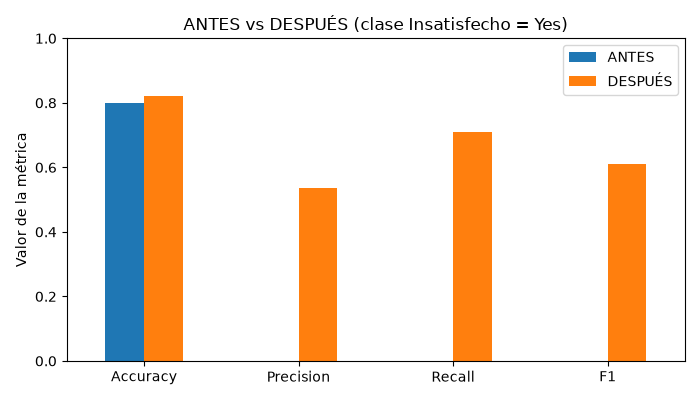

In [ ]:
import matplotlib.pyplot as plt

ax = comparacion[["ANTES", "DESPUÉS"]].plot(kind="bar", figsize=(7, 4), rot=0)
ax.set_ylabel("Valor de la métrica")
ax.set_title("ANTES vs DESPUÉS (clase Insatisfecho = Yes)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Verificaciones

In [ ]:
# 1) Se usan exactamente 10 variables y ninguna prohibida
prohibidas = {"customer_satisfaction", "interaction_id", "customer_id", "timestamp"}
assert len(features_despues) == 10 and not prohibidas & set(features_despues)
# 2) Split correcto: 25 % para prueba y clases estratificadas
assert len(X_test) == round(len(df) * 0.25)
print("Proporción de insatisfechos -> train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))
# 3) Las matrices suman el total de prueba
assert confusion_matrix(y_test, pred_antes).sum() == confusion_matrix(y_test, pred_despues).sum() == len(y_test)
# 4) El modelo ANTES reproduce la salida original del proyecto (accuracy 0.8009, sin detectar insatisfechos)
assert round(accuracy_score(y_test, pred_antes), 4) == 0.8009 and pred_antes.sum() == 0
print("Todas las verificaciones pasaron")

Proporción de insatisfechos -> train: 0.1997 | test: 0.1991
Todas las verificaciones pasaron


## 6. Explicación propia
El modelo original parecía bueno porque tenía 80 % de accuracy, pero en realidad no servía. Decía "No" a todos los clientes y nunca detectaba a los insatisfechos. Sacaba 80 % solo porque el 80 % de los clientes ya está satisfecho.

Para mejorarlo hice tres cosas:

1. **Le di más datos.** Pasé de 3 a 10 variables. Una de ellas, el día de la semana, la saqué de la fecha.
2. **Preparé los datos.** Rellené los vacíos, puse los números en la misma escala y convertí las categorías en 0 y 1 para que el modelo las entienda. Todo se aprende solo con los datos de entrenamiento, para no hacer trampa.
3. **Le dije que los insatisfechos importan.** Con `class_weight="balanced"`, equivocarse con ellos pesa más.

Comparé el antes y el después con los mismos datos de prueba. El accuracy casi no cambió (0,80 a 0,82), pero el recall pasó de 0 a 0,71. Ahora detecta 159 de 224 insatisfechos. A cambio hay 137 falsas alarmas, que me parece aceptable porque llamar a un cliente que estaba conforme cuesta menos que perder a uno insatisfecho.

Es un modelo simple y los datos son sintéticos, así que no sé si funcionaría igual con clientes reales.